# Run quadratic parameterisation


Parameterisation example is quadratic local with mean Antarctic slope (= no slope dependency) as defined in Burgard et al. (2022).
Based on code initially created by Clara Burgard, modfied and extended by Ronja Reese. Please note that we create the melt rates here, whereas in MeltMIP/ISMIP7 we ask modellers to use their parameterisation implemented in the ice sheet model to produce melt rates for parameter selection.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

import multimelt.melt_functions as meltf
from multimelt.constants import *

from parameter_selection_toolbox_v2 import *

2026-03-30 10:34:57.938033: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-30 10:34:57.938390: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-30 10:34:57.996377: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-30 10:34:59.532606: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

# Settings

In [3]:
# Directories
figure_dir = 'figures'
data_path="/media/NAS2/ISMIP7/share_with_modellers"
ensemble_path="/mnt/FastStore1/quadratic_out"


# Constants
yearlen = 365.14*24*60*60 # seconds per year
ice_density = 918 # kg/m3
reso=8000 # model resolution used for melt parameterisation [m]

# parameterisation ensemble table 
p1_name = 'K'
p2_name = 'dummy'


# Create data 
Note that this would be replaced with running your melt parameterisation. 

In [4]:
# Create parameter array
# Good set of K
#K = xr.DataArray(data=np.arange(0.25e-5,3.025e-4,0.25e-5), dims=['K_dim']).assign_coords({'K_dim': np.arange(0.25e-5,3.025e-4,0.25e-5)}) 

# Simple set of K
K = xr.DataArray(data=np.arange(1.0e-5,3.6e-4,1e-5), dims=['K_dim']).assign_coords({'K_dim': np.arange(1.0e-5,3.6e-4,1e-5)}) 

K

<xarray.DataArray (K_dim: 35)> Size: 280B
array([1.0e-05, 2.0e-05, 3.0e-05, 4.0e-05, 5.0e-05, 6.0e-05, 7.0e-05,
       8.0e-05, 9.0e-05, 1.0e-04, 1.1e-04, 1.2e-04, 1.3e-04, 1.4e-04,
       1.5e-04, 1.6e-04, 1.7e-04, 1.8e-04, 1.9e-04, 2.0e-04, 2.1e-04,
       2.2e-04, 2.3e-04, 2.4e-04, 2.5e-04, 2.6e-04, 2.7e-04, 2.8e-04,
       2.9e-04, 3.0e-04, 3.1e-04, 3.2e-04, 3.3e-04, 3.4e-04, 3.5e-04])
Coordinates:
  * K_dim    (K_dim) float64 280B 1e-05 2e-05 3e-05 ... 0.00033 0.00034 0.00035

In [5]:
# Load climatology
climatology = xr.load_dataset(os.path.join(data_path, "climatology", "zhou_annual_06_nov", "OI_Climatology_ismip8km_60m_tf_extrap.nc"))
salinity = xr.load_dataset(os.path.join(data_path, "climatology", "zhou_annual_06_nov","OI_Climatology_ismip8km_60m_so_extrap.nc"))

# Load BedMap3
bed = xr.load_dataset(os.path.join(data_path, "topography", "bedmap3_ismip_8km.nc"))

# Load imbie2 basins as used on ISMIP
basins = xr.load_dataset(os.path.join(data_path, 'imbie2', "basin_numbers_ismip8km_v2.nc"))
basins = basins.rename({'basinNumber':'basins'}) # basins start at 0
nBasins = int(basins.basins.max())

In [6]:
# Present-day melt rates

model_runs = [] 
p1s = []


# get thermal forcing at the ice shelf draft
tf_draft = climatology.tf.sel(z=bed['draft'], method='nearest')
tf_draft = tf_draft.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
so_draft = salinity.so.sel(z=bed['draft'], method='nearest')
#so_draft = so_draft.where(so_draft>0, 0) # remove negative values
S0 = so_draft.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
U_factor = (c_po / L_i) * beta_coeff_lazero * (g/(2*abs(f_coriolis))) * S0

for i,k in enumerate(K):

    p1s.append(k)
    
    thermal_forcing = (tf_draft).where(bed.floating_frac>0.5, np.nan)
    # melt rates in kg/m2/a
    ds = meltf.quadratic_mixed_slope(k, melt_factor, thermal_forcing, thermal_forcing, U_factor, np.arcsin(2.9e-3))*yearinsec*ice_density
    #ds.to_netcdf(os.path.join(ensemble_path,"pd_zhou_"+str(i)+".nc")) 
    #ds = ds.assign_coords(p1=k)
    model_runs.append(ds)

print('Combining datasets')
pd_ensemble = xr.concat(model_runs, dim='K_dim')

pd_ensemble = pd_ensemble.rename({'K_dim':'p1'})
#pd_ensemble = pd_ensemble.expand_dims({"p2": np.ones(pd_ensemble.sizes['p1'])})
pd_ensemble = pd_ensemble.expand_dims({"p2": np.ones(1)})

pd_ensemble.name = "melt_rate"
pd_ensemble = pd_ensemble.to_dataset()

Combining datasets


In [10]:
# Ocean Modelling 


def apply_ocean_modelling_melt(model_names):
    ensembles = []
    
    for j,model in enumerate(model_names):
        print(model)
        try:
            ocean_modelling_data = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Modelling_Data",model+"TF.nc"))
        except:
            # FIXME REMOVE THIS ONCE DATA IS FINALISED
            ocean_modelling_data = xr.load_dataset("/media/NAS2/ISMIP7/Tocheck/output/"+model+"TF.nc")
            
        # get thermal forcing at the ice shelf draft
        tf_draft_om = ocean_modelling_data.thermal_forcing.sel(z=bed['draft'], method='nearest')
        tf_draft_om = tf_draft_om.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
        try:
            salinity = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Modelling_Data",model+"S.nc"))
        except:
            salinity = xr.load_dataset("/media/NAS2/ISMIP7/Tocheck/output/"+model+"S.nc")
        # get thermal forcing at the ice shelf draft
        so_draft = salinity.salinity_ocean.sel(z=bed['draft'], method='nearest')
        S0 = so_draft.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
        
        U_factor = (c_po / L_i) * beta_coeff_lazero * (g/(2*abs(f_coriolis))) * S0
    
        model_runs = []
        for i,k in enumerate(K):
            thermal_forcing = (tf_draft_om).where(bed.floating_frac>0.5, np.nan)        
            ds = meltf.quadratic_mixed_slope(k, melt_factor, thermal_forcing, thermal_forcing, U_factor, np.arcsin(2.9e-3))*yearinsec*ice_density
            model_runs.append(ds)
    
        print('Combining datasets')
        
        ensemble = xr.concat(model_runs, dim='K_dim')
        ensemble = ensemble.rename({'K_dim':'p1'})
        #ensemble = ensemble.expand_dims({"p2": np.ones(pd_ensemble.sizes['p1'])})
        ensemble = ensemble.expand_dims({"p2": np.ones(1)})
        ensemble = ensemble.expand_dims({"model": np.array([j])})
        ensembles.append(ensemble)
        
    result = xr.concat(ensembles, dim='model')
    return result


# Save all modelling data into xarray dataset

model_names = ['Mathiot23_cold_v2_', "TimmermannUndGoeller2017_cold_v2_", "Naughten_FESOM_ACCESS_cold_", "Naughten_FESOM_MMM_cold_",
              'Naughten_MITgcmASE_ens01_cold_', 'Naughten_MITgcmASE_ens02_cold_', 'Naughten_MITgcmASE_ens03_cold_', 
               'Naughten_MITgcmASE_ens04_cold_','Naughten_MITgcmASE_ens05_cold_', 'Naughten_MITgcmASE_ens06_cold_', 
               'Naughten_MITgcmASE_ens07_cold_', 'Naughten_MITgcmASE_ens08_cold_', 'Naughten_MITgcmASE_ens09_cold_', 
               'Naughten_MITgcmASE_ens10_cold_', 'Naughten_MITgcmWS_1pctCO2_cold_', 'Naughten_MITgcmWS_4xCO2_cold_' ]
cold_ensemble = apply_ocean_modelling_melt(model_names)
cold_ensemble = cold_ensemble.assign_coords(model=["mathiot", "timmermann", "naughten_ais_1", "naughten_ais_2",
                                              "naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
                                              "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
                                              "naughten_ase_9","naughten_ase_10","naughten_ws_1", "naughten_ws_2"])
cold_ensemble.name = "melt_rate"
cold_ensemble = cold_ensemble.to_dataset()

model_names = [name.replace('cold', 'warm') for name in model_names]
warm_ensemble = apply_ocean_modelling_melt(model_names)
warm_ensemble = warm_ensemble.assign_coords(model=["mathiot", "timmermann", "naughten_ais_1", "naughten_ais_2",
                                              "naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
                                              "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
                                              "naughten_ase_9","naughten_ase_10","naughten_ws_1", "naughten_ws_2"])
warm_ensemble.name = "melt_rate"
warm_ensemble = warm_ensemble.to_dataset()


Mathiot23_cold_v2_
Combining datasets
TimmermannUndGoeller2017_cold_v2_
Combining datasets
Naughten_FESOM_ACCESS_cold_
Combining datasets
Naughten_FESOM_MMM_cold_
Combining datasets
Naughten_MITgcmASE_ens01_cold_
Combining datasets
Naughten_MITgcmASE_ens02_cold_
Combining datasets
Naughten_MITgcmASE_ens03_cold_
Combining datasets
Naughten_MITgcmASE_ens04_cold_
Combining datasets
Naughten_MITgcmASE_ens05_cold_
Combining datasets
Naughten_MITgcmASE_ens06_cold_
Combining datasets
Naughten_MITgcmASE_ens07_cold_
Combining datasets
Naughten_MITgcmASE_ens08_cold_
Combining datasets
Naughten_MITgcmASE_ens09_cold_
Combining datasets
Naughten_MITgcmASE_ens10_cold_
Combining datasets
Naughten_MITgcmWS_1pctCO2_cold_
Combining datasets
Naughten_MITgcmWS_4xCO2_cold_
Combining datasets
Mathiot23_warm_v2_
Combining datasets
TimmermannUndGoeller2017_warm_v2_
Combining datasets
Naughten_FESOM_ACCESS_warm_
Combining datasets
Naughten_FESOM_MMM_warm_
Combining datasets
Naughten_MITgcmASE_ens01_warm_
Combi

In [13]:
# set outside of Weddell Sea to nan
for model in ["timmermann","naughten_ws_1", "naughten_ws_2"]:
    cold_ensemble = cold_ensemble.where( (cold_ensemble.model!=model )| (basins.basins == 14), np.nan)
    warm_ensemble = warm_ensemble.where( (warm_ensemble.model!=model )| (basins.basins == 14), np.nan)


# set outside of ASE to nan
for model in ["naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
             "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
             "naughten_ase_9","naughten_ase_10",]:
    cold_ensemble = cold_ensemble.where( (cold_ensemble.model!=model )| (basins.basins == 9), np.nan)
    warm_ensemble = warm_ensemble.where( (warm_ensemble.model!=model )| (basins.basins == 9), np.nan)

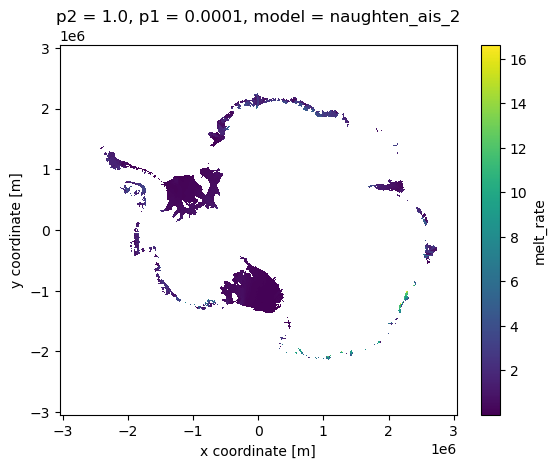

In [23]:
(cold_ensemble.sel(model='naughten_ais_2',p1=10e-5,p2=1).melt_rate/ice_density).plot()

In [8]:
# Ocean observations

def apply_ocean_observations_melt(dataset, years):
    ensembles = []
    for year in years:
        print(year)
        ocean_data = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Observations_Data",dataset+"_tf_"+str(year)+".nc"))
    
        # get thermal forcing at the ice shelf draft
        tf_draft_om = ocean_data.tf.sel(z=bed['draft'], method='nearest')
        tf_draft_om = tf_draft_om.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
    
        salinity = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Observations_Data",dataset+"_so_"+str(year)+".nc"))
        # get thermal forcing at the ice shelf draft
        so_draft = salinity.so.sel(z=bed['draft'], method='nearest')
        S0 = so_draft.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
        
        U_factor = (c_po / L_i) * beta_coeff_lazero * (g/(2*abs(f_coriolis))) * S0
    
        model_runs = []
        for i,k in enumerate(K):
            thermal_forcing = (tf_draft_om).where(bed.floating_frac>0.5, np.nan)        
            ds = meltf.quadratic_mixed_slope(k, melt_factor, thermal_forcing, thermal_forcing, U_factor, np.arcsin(2.9e-3))*yearinsec*ice_density
            model_runs.append(ds)
    
        print('Combining datasets')
        
        ensemble = xr.concat(model_runs, dim='K_dim')
        #print(ensemble)
        ensemble = ensemble.rename({'K_dim':'p1'})
        #ensemble = ensemble.expand_dims({"p2": np.ones(pd_ensemble.sizes['p1'])})
        ensemble = ensemble.expand_dims({"p2": np.ones(1)})
        ensemble = ensemble.expand_dims({"year": np.array([year])})
        ensembles.append(ensemble)
    result = xr.concat(ensembles, dim='year')
    return result


years = np.array([1994, 2000, 2006, 2007, 2009,2010,2011,2012,2014,2016,2018,2019,2020]) # Use all years
obs_ensemble = apply_ocean_observations_melt("Dutrieux_ismip8km_60m",years)
obs_ensemble.name = "melt_rate"
obs_ensemble = obs_ensemble.to_dataset()


1994
Combining datasets
2000
Combining datasets
2006
Combining datasets
2007
Combining datasets
2009
Combining datasets
2010
Combining datasets
2011
Combining datasets
2012
Combining datasets
2014
Combining datasets
2016
Combining datasets
2018
Combining datasets
2019
Combining datasets
2020
Combining datasets


# Load modellers provided data

In [24]:
# LOAD ENSEMBLES HERE

In [25]:
# load basins here at model grid resolution
basins_m = xr.load_dataset(os.path.join(data_path, 'imbie2', "basin_numbers_ismip8km_v2.nc"))
basins_m = basins_m.rename({'basinNumber':'basins'}) # basins start at 0

# load buttressing bins at model grid resolution
bfrn_m = xr.load_dataset(os.path.join(data_path, 'parameterisations',"BFRN_ismip8km_v2.nc"))

# load mask that is 1 if ice is floating and 0 if grounded on model grid resolution
bed = xr.load_dataset(os.path.join(data_path, "topography", "bedmap3_ismip_8km.nc"))
mask_m = bed.floating_frac>0.5

# Load data for optimisation

In [26]:
# Ice shelf masks for PIG and Dotson for term 4

ds = xr.load_dataset(os.path.join(data_path, 'parameterisations',"shelf_mask_ismip8km.nc"))#.isel(time=0)
shelves = ds.shelf_mask.isel(time=0)
pig_id = 110
dis_id = 97
pig = (shelves==pig_id)
dotson = (shelves==dis_id) 
pigdotson_mask = pig.astype(int) + dotson.astype(int) * 2
label_map = {1: "pig", 2: "dotson"}
labels = np.vectorize(label_map.get)(pigdotson_mask.values)
region_label = xr.DataArray(labels, dims=pigdotson_mask.dims, coords=pigdotson_mask.coords)

In [27]:
# Interpolate to model resolution

pigdotson_mask_m = pigdotson_mask.interp(method='nearest')
labels = np.vectorize(label_map.get)(pigdotson_mask_m.values)
region_label_m = xr.DataArray(labels, dims=pigdotson_mask_m.dims, coords=pigdotson_mask_m.coords)

# Load melt rate targets

In [28]:
MeltDataImbie = pd.read_csv(os.path.join(data_path, 'parameterisations','Melt_Paolo_Err_Adusumilli_imbie2_v2.csv'), index_col=0) # Aggregated per imbier basin

buttressing_target = xr.load_dataset(os.path.join(data_path, 'parameterisations',"melt_target_term2.nc"))

cold_target = xr.load_dataset(os.path.join(data_path, 'parameterisations',"melt_cold_target_term3.nc"))
warm_target = xr.load_dataset(os.path.join(data_path, 'parameterisations',"melt_warm_target_term3.nc"))

t4_obs = xr.load_dataset(os.path.join(data_path, 'parameterisations',"melt_observations_target_term4.nc"))

# Calculate Terms 

In [29]:
cvt_m = reso**2  / 1e12  # to convert to Gt/a
cvt = 8000**2  / 1e12  # to convert to Gt/a

In [30]:
# Term 1
t1_model, t1_obs_mean, t1_obs_sigma = calculate_term1(
    pd_ensemble,mask_m,basins_m['basins'],nBasins,cvt_m,MeltDataImbie)

In [31]:
# Term 2
t2_model, t2_obs_mean, t2_obs_sigma = calculate_term2(
    pd_ensemble,mask_m,bfrn_m,cvt_m,buttressing_target)

In [32]:
# Term 3
t3_model, t3_obs_mean, t3_obs_sigma = calculate_term3(
    cold_ensemble, warm_ensemble, cold_target, warm_target,
    mask_m,basins_m['basins'])

In [33]:
# Term 4
t4_model, t4_obs_mean, t4_obs_sigma = calculate_term4(obs_ensemble, region_label_m, t4_obs, mask_m, cvt_m)

# Introduce weights

In [34]:
#(basins.basins==4).plot()

In [35]:
t1_weights = xr.DataArray(
    t1_obs_mean*0+1,
    dims=["basins"],
    coords={"basins": t1_model.basins.values}
)

# e.g., to sample only FRIS, Ross, Totten and ASE
#t1_weights = t1_weights.where( (t1_weights.basins==9) | 
#                               (t1_weights.basins==14) | 
#                               (t1_weights.basins==7) |
#                               (t1_weights.basins==4), 0)
#t1_weights = t1_weights *0

In [36]:
# Buttressing Flux Response Numbers, remapped to 8km 
bfrn = xr.load_dataset(os.path.join(data_path, 'parameterisations',"BFRN_ismip8km_v2.nc"))

t2_weight = (bfrn['BFRN_medians'] / bfrn['BFRN_median']).values

t2_weights = xr.DataArray(
    t2_weight,
    dims=["BFRN_bins"],
    coords={"BFRN_bins": t2_obs_mean.BFRN_bins.values}
)



In [37]:
weights_data = np.ones(t3_model.isel(p1=0,p2=0).shape) 

t3_weights = xr.DataArray(
    weights_data,
    dims=["model", "basins"],
    coords={"model": t3_obs_mean.model.values,
            "basins": t3_obs_mean.basins.values}
)

# NOW test whatever weights you want to, for example:
#t3_weights = t3_weights.where(t3_weights.model == "timmermann", other=0)
# sample only FRIS, Ross, and Totten, ASE
#t3_weights = t3_weights.where( (t1_weights.basins==9) | 
#                               (t1_weights.basins==14) | 
#                               (t1_weights.basins==7) |
#                               (t1_weights.basins==4), other=0)

#t3_weights = t3_weights.where( (t1_weights.basins==9) | 
#                               (t1_weights.basins==4), other=0)

#t3_weights = t3_weights *0

In [38]:
# introduce weights, shape of region, years

weights_data = np.ones(t4_model.isel(p1=0,p2=0).shape)

t4_weights = xr.DataArray(
    weights_data,
    dims=["year", "region"],
    coords={"year": t4_obs.year.values,
            "region": t4_obs.region.values}
)

# FIXME select here: only PIG or Dotson, or certain years!

#t4_weights = t4_weights.where(t4_weights.region == "dotson", other=0)
#t4_weights = t4_weights.where(t4_weights.region == "pig", other=0)
# where both datasets have data
#t4_weights = t4_weights.where( (t4_weights.year ==2007) | (t4_weights.year==2009) |  (t4_weights.year==2012) |(t4_weights.year==2014) |
#                         (t4_weights.year==2016) ,other=0)
# single year
#t4_weights = t4_weights.where( (t4_weights.year ==2009)  ,other=0)

#t4_weights

# Calculate objective function 

In [39]:
sample_size=10000


min_p1, min_p2 = calculate_objective_function(
    sample_size,
    reso,
    t1_model, t1_obs_mean, t1_obs_sigma,t1_weights,
    t2_model, t2_obs_mean, t2_obs_sigma,t2_weights,
    t3_model, t3_obs_mean, t3_obs_sigma,t3_weights,
    t4_model, t4_obs_mean, t4_obs_sigma,t4_weights)

Text(0.5, 1.0, 'Optimal K')

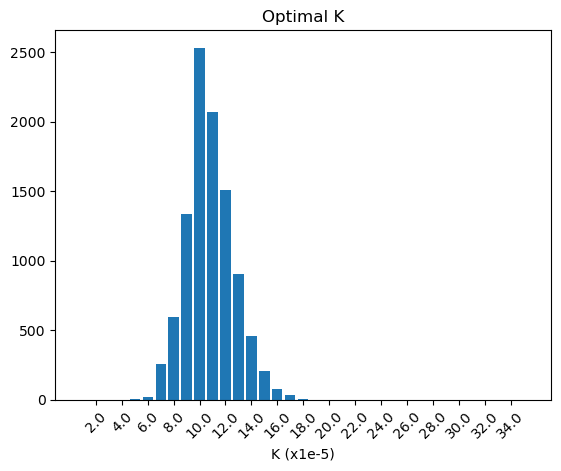

In [40]:
# PLOT
fig,axes = plt.subplots(1,1, sharex=False, sharey=False)
ax = axes

bin_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+1e-7) )
counts, bins = np.histogram(np.array(min_p1), bins= bin_edges)
positions = np.arange(len(pd_ensemble.p1.values))
ax.bar(positions, counts, width=0.8)   
labels = np.round(pd_ensemble.p1.values*1e5, 1)
ax.set_xticks(positions[1::2], labels[1::2], rotation=45)
ax.set_xlabel('K (x1e-5)')
ax.set_title('Optimal K')


#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic.png'))   


In [41]:
# Find min, max, 5th, 95th, and modes

print('Start exploring median or mode:')
print('median = ', np.median(np.array(min_p1)))
print('mode = ', pd_ensemble.p1.values[np.argmax(counts) ])


print('Uncertainty bounds:')
print('5th = ', np.percentile(np.array(min_p1), 5))
print('95th = ', np.percentile(np.array(min_p1), 95))


print('Further options for uncertainty exploration:')
print('min = ', np.min(np.array(min_p1)))
print('1st = ', np.percentile(np.array(min_p1), 1))
print('99th = ', np.percentile(np.array(min_p1), 99))
print('max = ', np.max(np.array(min_p1)))

vals = [np.min(np.array(min_p1)), np.percentile(np.array(min_p1), 1), 
        np.percentile(np.array(min_p1), 5), np.median(np.array(min_p1)), 
        np.percentile(np.array(min_p1), 95), np.percentile(np.array(min_p1), 99),
        np.max(np.array(min_p1))
       ]
labs = ['min', '1st', '5th', '50th', '95th', '99th', 'max']


# Find local maxima for modes, 
peaks, _ = find_peaks(counts)
modes = pd_ensemble.p1.values[peaks]
print('Modes = ', modes)

Start exploring median or mode:
median =  0.00011
mode =  0.0001
Uncertainty bounds:
5th =  8e-05
95th =  0.00014000000000000001
Further options for uncertainty exploration:
min =  4e-05
1st =  7.000000000000001e-05
99th =  0.00016
max =  0.00018
Modes =  [0.0001]


Text(0.5, 1.0, 'Optimal K, percentiles')

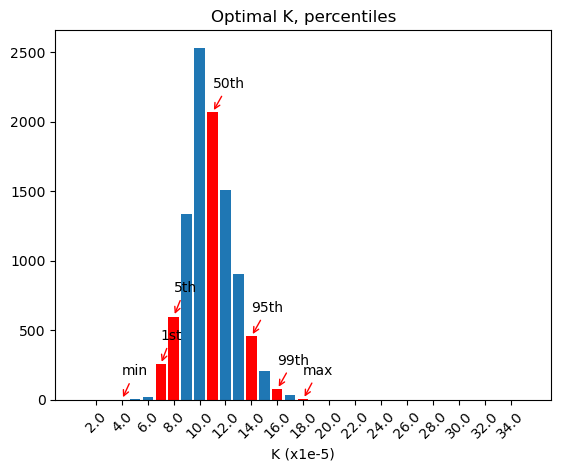

In [42]:
fig,axes = plt.subplots(1,1, sharex=False, sharey=False)
ax = axes

bin_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+1e-7) )
counts, bins = np.histogram(np.array(min_p1), bins= bin_edges)
positions = np.arange(len(pd_ensemble.p1.values))
ax.bar(positions, counts, width=0.8)
#ax.set_ylim([0,350])
for i,val in enumerate(vals):
    bin_index = np.digitize(val, bin_edges) - 1
    ax.patches[bin_index].set_facecolor('red')
    bin_center = bin_index #(bin_edges[bin_index] + bin_edges[bin_index+1]) / 2
    plt.annotate(labs[i], xy=(bin_center, counts[bin_index]), 
                 xytext=(bin_center, counts[bin_index]+175),
                 arrowprops=dict(arrowstyle='->', color='red'))

labels = np.round(pd_ensemble.p1.values*1e5, 1)
ax.set_xticks(positions[1::2], labels[1::2], rotation=45)
ax.set_xlabel('K (x1e-5)')
ax.set_title('Optimal K, percentiles')


#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_sample'+str(sample_size)+'_'+optimise+'as_percentiles.png')) 
#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_sample'+str(sample_size)+'_'+optimise+'_percentiles.png'))   


Text(0.5, 1.0, 'Optimal K, modes')

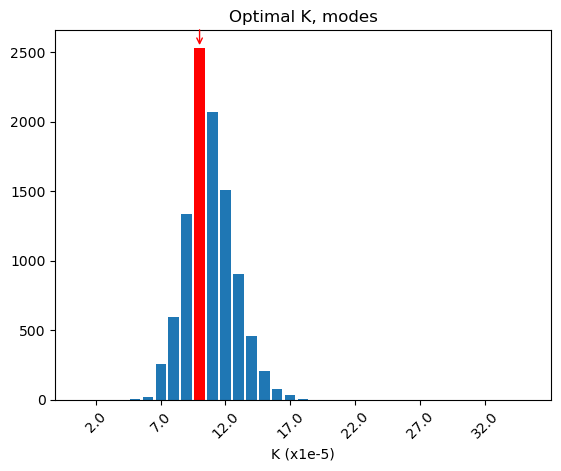

In [43]:
fig,axes = plt.subplots(1,1, sharex=False, sharey=False)
ax = axes

bin_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+1e-7) )
counts, bins = np.histogram(np.array(min_p1), bins= bin_edges)
positions = np.arange(len(pd_ensemble.p1.values))
ax.bar(positions, counts, width=0.8)
#ax.set_ylim([0,750])

for mode in modes:
    bin_index = np.digitize(mode, bin_edges) - 1 # FIXME this is not working!
    ax.patches[bin_index].set_facecolor('red')
    bin_center = bin_index 
    plt.annotate('', xy=(bin_center, counts[bin_index]), 
                 xytext=(bin_center, counts[bin_index]+150),
                 arrowprops=dict(arrowstyle='->', color='red'))

labels = np.round(pd_ensemble.p1.values*1e5, 1)
ax.set_xticks(positions[1::5], labels[1::5], rotation=45)
ax.set_xlabel('K (x1e-5)')
ax.set_title('Optimal K, modes')


#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_sample'+str(sample_size)+'_'+optimise+'as_modes.png')) 
#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_sample'+str(sample_size)+'_'+optimise+'_modes.png'))   


# Select K value

Select a parameter value from above, e.g., the median or mode, and calculate deltaT to fit present-day, basin-wide melt (basically Term 1).

In [60]:
K = 14e-5

In [61]:
# compare to gT from Jourdain et al., 20220
S0=34.5
sintheta = 2.9e-3
gT_to_K = 2*abs(f_coriolis)*rho_sw/(rho_i*g*beta_coeff_lazero*S0*sintheta*yearinsec)

print("This corresponds roughly to \gamma_T= ", np.round(K/gT_to_K), "m/a from Jourdain et al., 2020")

This corresponds roughly to \gamma_T=  10858.0 m/a from Jourdain et al., 2020


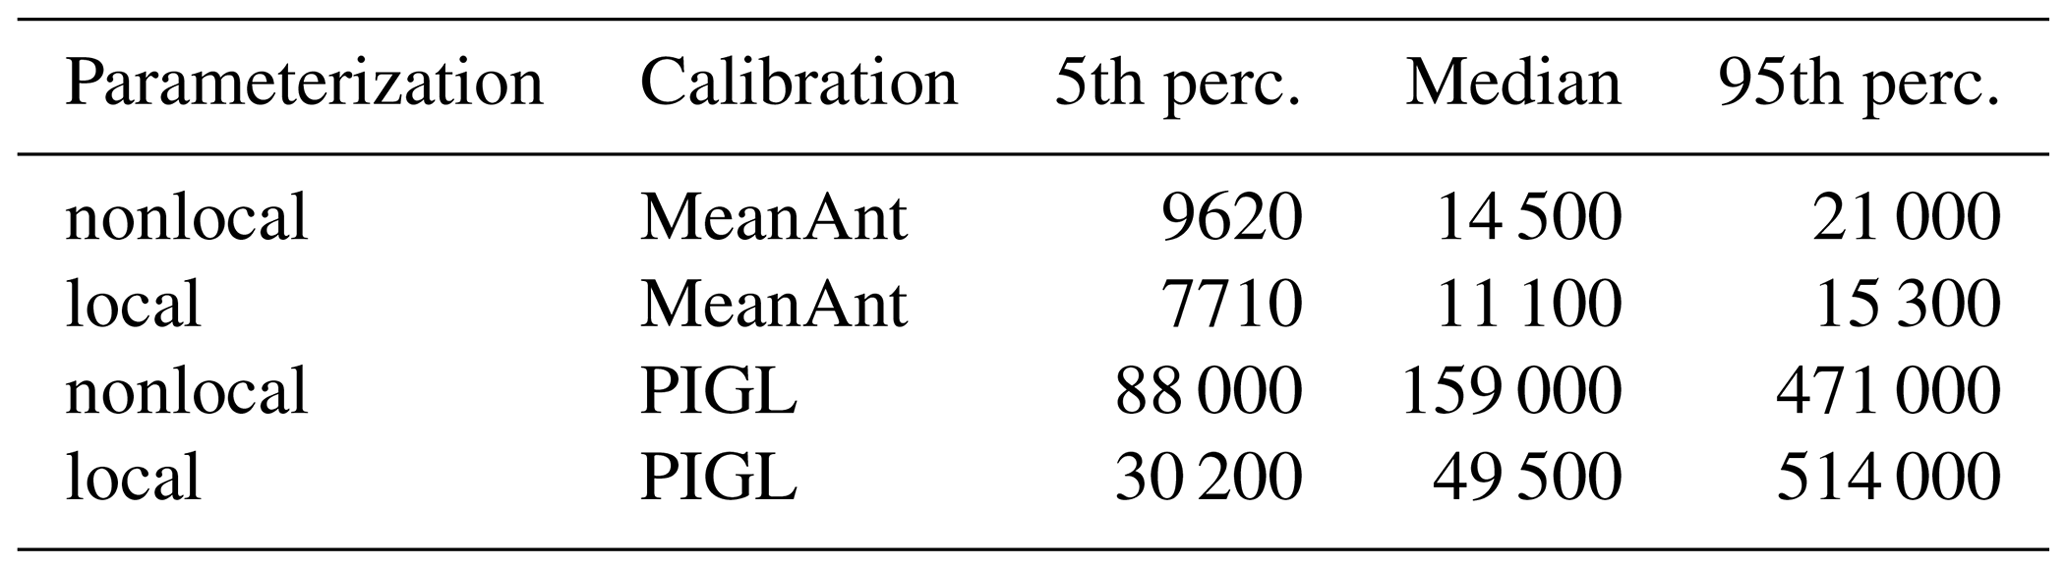

# Optimise deltaT - optional

First calculate melt rates with the chose K for a range of deltaT corrections (applied uniformly to the whole continent). Note that this should be done within the model parametererisation.

In [46]:
# Create deltaT corrections array
deltaT = np.linspace(-2,2,101) 

# calculate melt rates for uniform deltaT 
members = []
for dT in deltaT:      
    thermal_forcing = (tf_draft+dT).where(mask_m, np.nan)        
    ds = meltf.quadratic_mixed_slope(K, melt_factor, thermal_forcing, thermal_forcing, U_factor, np.arcsin(2.9e-3))*yearinsec*ice_density
    ds = ds.assign_coords(deltaT=dT)
    members.append(ds)
dT_ensemble = xr.concat(members, dim='deltaT', coords='minimal')

In [47]:
result_ds = optimise_deltaT(dT_ensemble, basins_m['basins'], reso,  MeltDataImbie)

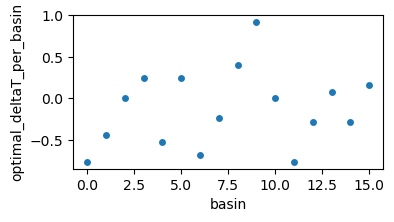

In [48]:
plt.figure(figsize=(4,2))
result_ds.optimal_deltaT_per_basin.plot.scatter()

In [50]:
# here we calculate melt rates, using deltaT for the ocean modelling data. This should be done with the melt parameterisation

def apply_deltaT_to_dataset(model_names, optimal_deltaT_per_basin):
    results = []
    
    for j,model in enumerate(model_names):
        print(model)
        
        number_of_basins = int(len(optimal_deltaT_per_basin))-1
        try:
            ocean_modelling_data = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Modelling_Data",model+"TF.nc"))
        except:
            # FIXME REMOVE THIS ONCE DATA IS FINALISED
            ocean_modelling_data = xr.load_dataset("/media/NAS2/ISMIP7/Tocheck/output/"+model+"TF.nc")
        # get thermal forcing at the ice shelf draft
        tf_draft_om = ocean_modelling_data.thermal_forcing.sel(z=bed['draft'], method='nearest')
        tf_draft_om = tf_draft_om.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
    
        try:
            ocean_modelling_data = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Modelling_Data",model+"S.nc"))# get thermal forcing at the ice shelf draft
        except:
            # FIXME REMOVE THIS ONCE DATA IS FINALISED
            ocean_modelling_data = xr.load_dataset("/media/NAS2/ISMIP7/Tocheck/output/"+model+"S.nc")
        so_draft = salinity.so.sel(z=bed['draft'], method='nearest')
        S0 = so_draft.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
        
        U_factor = (c_po / L_i) * beta_coeff_lazero * (g/(2*abs(f_coriolis))) * S0
        
        thermal_forcing = (tf_draft_om).where(bed.floating_frac>0.5, np.nan)  
        
        # Create spatial field from your 1D array
        basins_to_value = xr.DataArray(optimal_deltaT_per_basin, dims=['basins'], coords={'basins': range(number_of_basins+1)})
        spatial_values = basins_to_value.sel(basins=basins['basins'])
    
        # Add to existing field
        thermal_forcing = thermal_forcing + spatial_values
        ds = meltf.quadratic_mixed_slope(K, melt_factor, thermal_forcing, thermal_forcing, U_factor, np.arcsin(2.9e-3))*yearinsec*ice_density
        
        ds = ds.expand_dims({"model": np.array([j])})
        results.append(ds)
        
    result = xr.concat(results, dim='model')
    return result



model_names = ['Mathiot23_cold_v2_', "TimmermannUndGoeller2017_cold_v2_", "Naughten_FESOM_ACCESS_cold_", "Naughten_FESOM_MMM_cold_",
              'Naughten_MITgcmASE_ens01_cold_', 'Naughten_MITgcmASE_ens02_cold_', 'Naughten_MITgcmASE_ens03_cold_', 
               'Naughten_MITgcmASE_ens04_cold_','Naughten_MITgcmASE_ens05_cold_', 'Naughten_MITgcmASE_ens06_cold_', 
               'Naughten_MITgcmASE_ens07_cold_', 'Naughten_MITgcmASE_ens08_cold_', 'Naughten_MITgcmASE_ens09_cold_', 
               'Naughten_MITgcmASE_ens10_cold_', 'Naughten_MITgcmWS_1pctCO2_cold_', 'Naughten_MITgcmWS_4xCO2_cold_' ]
cold_results = apply_deltaT_to_dataset(model_names,result_ds.optimal_deltaT_per_basin.values)
cold_results = cold_results.assign_coords(model=["mathiot", "timmermann", "naughten_ais_1", "naughten_ais_2",
                                              "naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
                                              "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
                                              "naughten_ase_9","naughten_ase_10","naughten_ws_1", "naughten_ws_2"])
cold_results.name = "melt_rate"
cold_results = cold_results.to_dataset()

model_names = [name.replace('cold', 'warm') for name in model_names]
warm_results = apply_deltaT_to_dataset(model_names,result_ds.optimal_deltaT_per_basin.values)
warm_results = warm_results.assign_coords(model=["mathiot", "timmermann", "naughten_ais_1", "naughten_ais_2",
                                              "naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
                                              "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
                                              "naughten_ase_9","naughten_ase_10","naughten_ws_1", "naughten_ws_2"])
warm_results.name = "melt_rate"
warm_results = warm_results.to_dataset()

# replace warm and cold basins other than FRIS with NaN in TimmermannAndGoeller datasets
cold_results = cold_results.where( (cold_results.model!='timmermann' )| (basins.basins==14) , np.nan)
warm_results = warm_results.where( (warm_results.model!='timmermann' )| (basins.basins==14) , np.nan)



# set outside of Weddell Sea to nan
for model in ["timmermann","naughten_ws_1", "naughten_ws_2"]:
    cold_results = cold_results.where( (cold_results.model!=model )| (basins.basins == 14), np.nan)
    warm_results = warm_results.where( (warm_results.model!=model )| (basins.basins == 14), np.nan)


# set outside of ASE to nan
for model in ["naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
             "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
             "naughten_ase_9","naughten_ase_10",]:
    cold_results = cold_results.where( (cold_results.model!=model )| (basins.basins == 9), np.nan)
    warm_results = warm_results.where( (warm_results.model!=model )| (basins.basins == 9), np.nan)

Mathiot23_cold_v2_
TimmermannUndGoeller2017_cold_v2_
Naughten_FESOM_ACCESS_cold_
Naughten_FESOM_MMM_cold_
Naughten_MITgcmASE_ens01_cold_
Naughten_MITgcmASE_ens02_cold_
Naughten_MITgcmASE_ens03_cold_
Naughten_MITgcmASE_ens04_cold_
Naughten_MITgcmASE_ens05_cold_
Naughten_MITgcmASE_ens06_cold_
Naughten_MITgcmASE_ens07_cold_
Naughten_MITgcmASE_ens08_cold_
Naughten_MITgcmASE_ens09_cold_
Naughten_MITgcmASE_ens10_cold_
Naughten_MITgcmWS_1pctCO2_cold_
Naughten_MITgcmWS_4xCO2_cold_
Mathiot23_warm_v2_
TimmermannUndGoeller2017_warm_v2_
Naughten_FESOM_ACCESS_warm_
Naughten_FESOM_MMM_warm_
Naughten_MITgcmASE_ens01_warm_
Naughten_MITgcmASE_ens02_warm_
Naughten_MITgcmASE_ens03_warm_
Naughten_MITgcmASE_ens04_warm_
Naughten_MITgcmASE_ens05_warm_
Naughten_MITgcmASE_ens06_warm_
Naughten_MITgcmASE_ens07_warm_
Naughten_MITgcmASE_ens08_warm_
Naughten_MITgcmASE_ens09_warm_
Naughten_MITgcmASE_ens10_warm_
Naughten_MITgcmWS_1pctCO2_warm_
Naughten_MITgcmWS_4xCO2_warm_


In [51]:
# Apply deltaT to ocean observations term

# Ocean observations

def apply_deltaT_to_obsterm(dataset, years, optimal_deltaT_per_basin):
    results = []
    for j,year in enumerate(years):
        print(year)
        ocean_data = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Observations_Data",dataset+"_tf_"+str(year)+".nc"))
    
        # get thermal forcing at the ice shelf draft
        tf_draft_om = ocean_data.tf.sel(z=bed['draft'], method='nearest')
        tf_draft_om = tf_draft_om.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
    
        salinity = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Observations_Data",dataset+"_so_"+str(year)+".nc"))
        # get thermal forcing at the ice shelf draft
        so_draft = salinity.so.sel(z=bed['draft'], method='nearest')
        S0 = so_draft.where(bed.floating_frac>0.5, np.nan) # mask everything outside of ice shelves
        
        U_factor = (c_po / L_i) * beta_coeff_lazero * (g/(2*abs(f_coriolis))) * S0
    
        # Create spatial field from your 1D array
        number_of_basins = int(len(optimal_deltaT_per_basin))-1
        basins_to_value = xr.DataArray(optimal_deltaT_per_basin, dims=['basins'], coords={'basins': range(number_of_basins+1)})
        spatial_values = basins_to_value.sel(basins=basins['basins'])
    
        # Add to existing field
        thermal_forcing = tf_draft_om + spatial_values
        ds = meltf.quadratic_mixed_slope(K, melt_factor, thermal_forcing, thermal_forcing, U_factor, np.arcsin(2.9e-3))*yearinsec*ice_density

        ds = ds.expand_dims({"year": np.array([year])})
        results.append(ds)
        
    result = xr.concat(results, dim='year')
        
    return result


years = np.array([1994, 2000, 2006, 2007, 2009,2010,2011,2012,2014,2016,2018,2019,2020]) # Use all years
obs_results = apply_deltaT_to_obsterm("Dutrieux_ismip8km_60m",years, result_ds.optimal_deltaT_per_basin.values)
obs_results.name = "melt_rate"
obs_results = obs_results.to_dataset()

1994
2000
2006
2007
2009
2010
2011
2012
2014
2016
2018
2019
2020


# Create plots

Text(0.5, 1.0, 'Present-day melt rates')

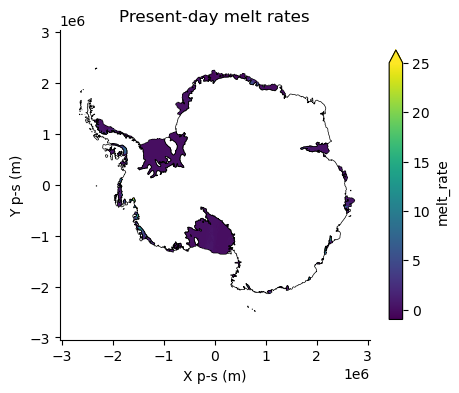

In [52]:
plt.figure(figsize=(5,5))

(result_ds.melt_rate/ice_density).plot( vmin=-1, vmax=25, cmap='viridis',cbar_kwargs={'shrink': 0.7} )
ax = plt.gca()
ax.set_aspect('equal')
ax.set_xlabel('X p-s (m)')
ax.set_ylabel('Y p-s (m)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.contour(result_ds.x, result_ds.y, bed.ocean_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.contour(result_ds.x, result_ds.y, bed.floating_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.title('Present-day melt rates')

#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_K'+str(K)+'_pdmelt.png'))  

Text(0.5, 1.0, 'Mathiot cold melt rates')

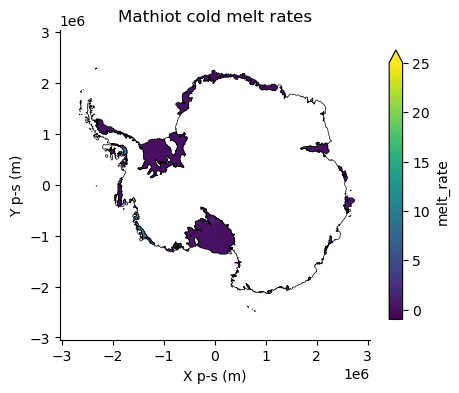

In [53]:
plt.figure(figsize=(5,5))

(cold_results.sel(model='mathiot').melt_rate/ice_density).plot(vmin=-1, vmax=25, cmap='viridis',cbar_kwargs={'shrink': 0.7} )
ax = plt.gca()
ax.set_aspect('equal')
ax.set_xlabel('X p-s (m)')
ax.set_ylabel('Y p-s (m)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.contour(result_ds.x, result_ds.y, bed.ocean_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.contour(result_ds.x, result_ds.y, bed.floating_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.title('Mathiot cold melt rates')
#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_K'+str(K)+'_mathiotcoldmelt.png'))  

Text(0.5, 1.0, 'Mathiot warm melt rates')

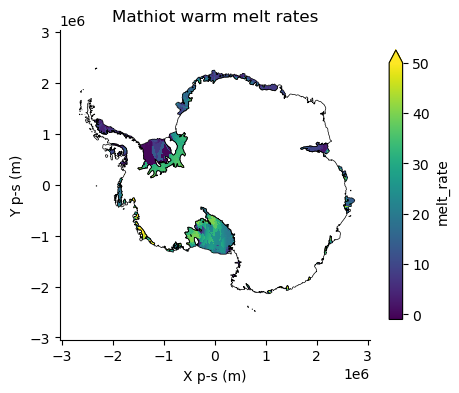

In [54]:
plt.figure(figsize=(5,5))

(warm_results.sel(model='mathiot').melt_rate/ice_density).plot( vmin=-1, vmax=50, cmap='viridis',cbar_kwargs={'shrink': 0.7} )
ax = plt.gca()
ax.set_aspect('equal')
ax.set_xlabel('X p-s (m)')
ax.set_ylabel('Y p-s (m)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.contour(result_ds.x, result_ds.y, bed.ocean_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.contour(result_ds.x, result_ds.y, bed.floating_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.title('Mathiot warm melt rates')

#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_K'+str(K)+'_mathiotwarmmelt.png'))  

# Plot individual terms

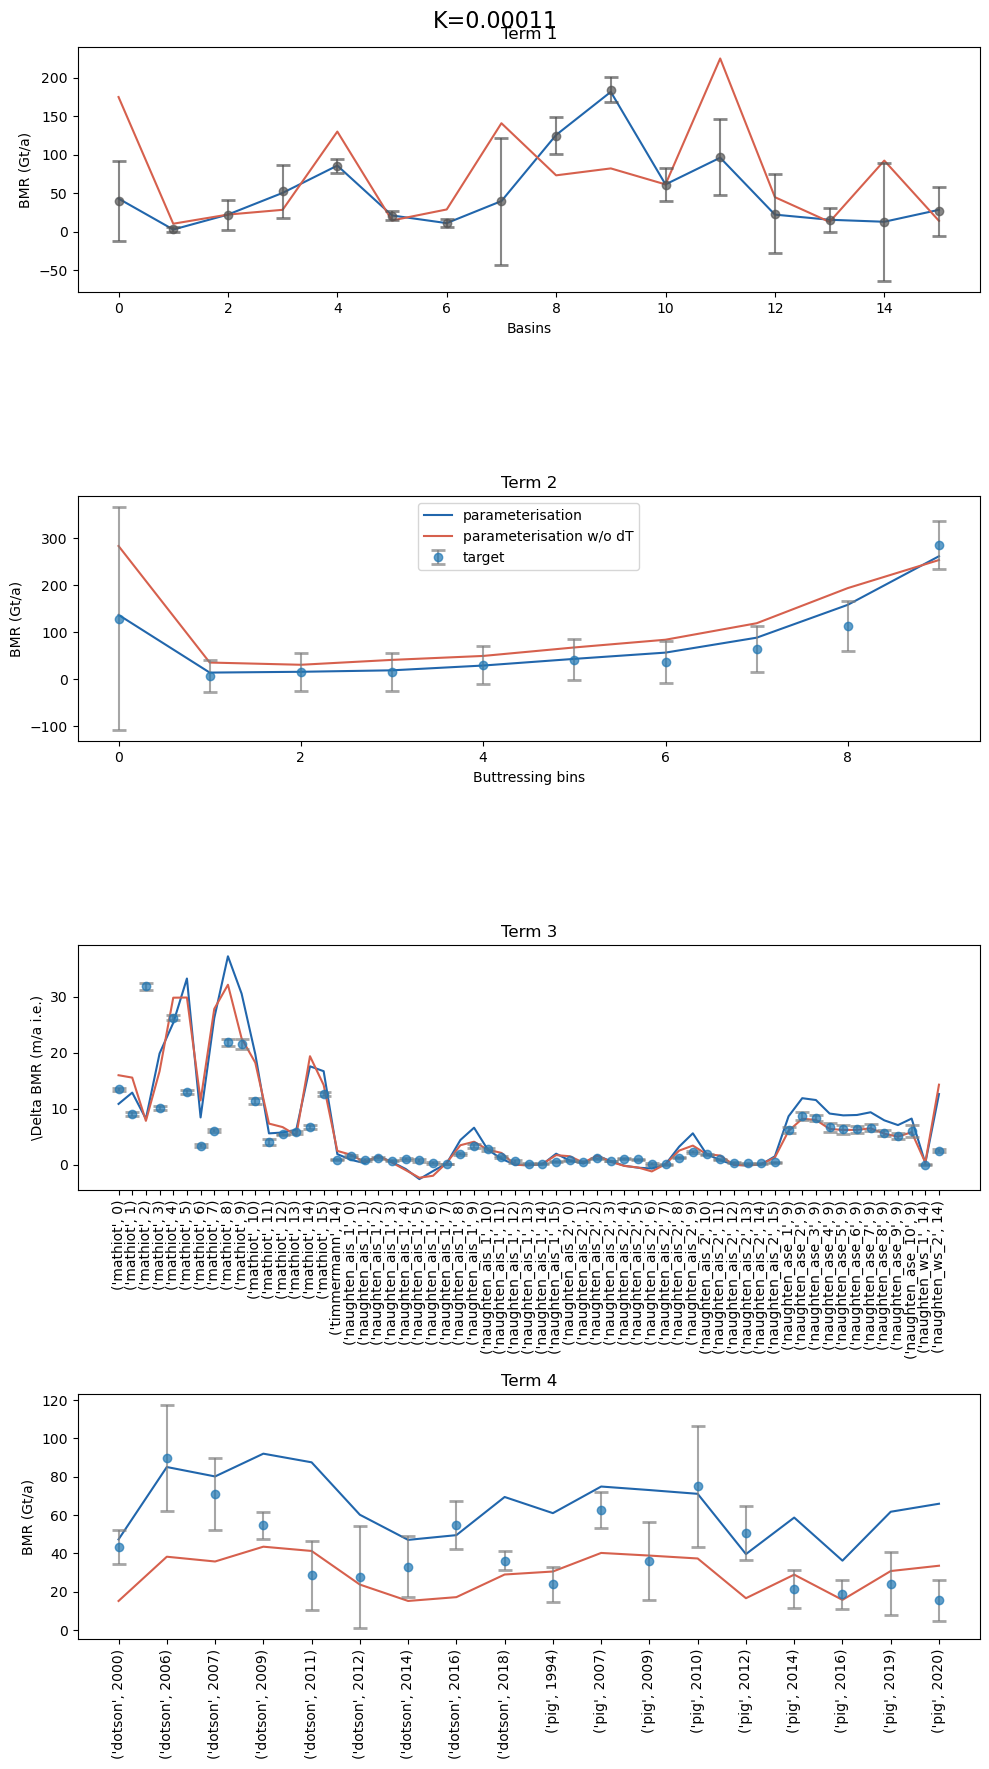

In [59]:
# Basic 2x2 grid

cvt = 8000**2  / 1e12  # to convert to Gt/a
cvt_m = reso**2  / 1e12  # to convert to Gt/a

fig, axes = plt.subplots(4, 1, figsize=(10, 18))

color_wocorrection = "#D6604D"
color_wcorrection = "#2166AC"

# TERM 1
ax = axes[0]  

t1_model_ndT, t1_obs_mean_ndT, t1_obs_sigma_ndT = calculate_term1(
    pd_ensemble.sel(p1=K,p2=1), mask_m, basins_m.basins, nBasins, cvt_m, MeltDataImbie)

t1_model, t1_obs_mean, t1_obs_sigma = calculate_term1(
    result_ds, mask_m, basins_m.basins, nBasins, cvt_m, MeltDataImbie)

ax.plot(range(nBasins+1),t1_model , label='parameterisation', color=color_wcorrection)
ax.plot(range(nBasins+1),t1_model_ndT , label='parameterisation w/o dT', color=color_wocorrection)
ax.errorbar(range(nBasins+1), t1_obs_mean, xerr=None, yerr=t1_obs_sigma, 
             fmt='o', capsize=5, capthick=2, color="#555555", 
             ecolor="#555555", alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xlabel('Basins')
#plt.text(0,2, 'Modelled average melt = '+str(np.round(np.sum(t2_model).values))+' m/a' )
#plt.text(0,1, 'Observed average melt = '+str(np.round(np.sum(t2_obs_mean).values))+' m/a' )
#ax.legend()
ax.set_title('Term 1')


# TERM 2
ax = axes[1]  
t2_model_ndT, t2_obs_mean, t2_obs_sigma = calculate_term2(
    pd_ensemble.sel(p1=K,p2=1),mask_m,bfrn_m,cvt_m,buttressing_target)

t2_model, t2_obs_mean, t2_obs_sigma = calculate_term2(
    result_ds,mask_m,bfrn_m,cvt_m,buttressing_target)

ax.plot(range(len(t2_model.BFRN_bins)),t2_model , label='parameterisation', color=color_wcorrection)
ax.plot(range(len(t2_model.BFRN_bins)),t2_model_ndT , label='parameterisation w/o dT', color=color_wocorrection)
ax.errorbar(range(len(t2_model.BFRN_bins)), t2_obs_mean, xerr=None, yerr=t2_obs_sigma, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xlabel('Buttressing bins')
ax.legend()
ax.set_title('Term 2')


# Term 3
ax = axes[2]  

t3_model_ndT, t3_obs_mean, t3_obs_sigma = calculate_term3(
    cold_ensemble.sel(p1=K,p2=1), warm_ensemble.sel(p1=K,p2=1), cold_target, warm_target, mask_m, basins_m.basins)

t3_model, t3_obs_mean, t3_obs_sigma = calculate_term3(
    cold_results,warm_results, cold_target, warm_target, mask_m, basins_m.basins)

t3_stack = t3_model.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')
t3_stack_ndT = t3_model_ndT.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')

ax.plot(range(len(t3_stack.modelbasin)),
        t3_stack/ice_density , label='parameterisation', color=color_wcorrection)
ax.plot(range(len(t3_stack_ndT.modelbasin)),
        t3_stack_ndT/ice_density , label='parameterisation w/o dT', color=color_wocorrection)
ax.errorbar(range(len(t3_stack_ndT.modelbasin)), 
            t3_obs_mean.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')/ice_density, 
            xerr=None, yerr=t3_obs_sigma.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')/ice_density, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('\Delta BMR (m/a i.e.)')
ax.set_xticks(range(len(t3_stack.modelbasin)))
ax.set_xticklabels(t3_stack.modelbasin.values, rotation=90)
ax.set_title('Term 3')

## Term 4
ax = axes[3] 


t4_model_ndT, t4_obs_mean, t4_obs_sigma = calculate_term4(
    obs_ensemble.sel(p1=K,p2=1), region_label_m, t4_obs, mask_m, cvt_m)

t4_model, t4_obs_mean, t4_obs_sigma = calculate_term4(
    obs_results, region_label_m, t4_obs, mask_m, cvt_m)


ds_flat_ndT = t4_model_ndT.stack(region_year=("region", "year")).dropna(dim='region_year')
ds_flat = t4_model.stack(region_year=("region", "year")).dropna(dim='region_year')


ax.plot(range(len(ds_flat_ndT.region_year)),ds_flat_ndT.values , label='parameterisation w/o dT', color=color_wocorrection)
ax.plot(range(len(ds_flat.region_year)),ds_flat.values , label='parameterisation', color=color_wcorrection)

ax.errorbar(range(len(ds_flat.region_year)), 
            t4_obs_mean.stack(region_year=('region','year')).dropna(dim='region_year'), 
            xerr=None, 
            yerr=t4_obs_sigma.stack(region_year=('region','year')).dropna(dim='region_year'),
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xticks(range(len(ds_flat.region_year)))
ax.set_xticklabels(ds_flat.region_year.values, rotation=90)
ax.set_title('Term 4')

# Add overall title
fig.suptitle('K='+str(K), fontsize=16)


plt.tight_layout()
plt.show()

#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_K'+str(K)+'_Terms.png'))  